# Clasificación: Predicción de Pit Stop en Fórmula 1
1. Pandas Profiling
2. Preparación de Datos
3. División de los datos 70-30
4. Balanceo con SMOTE (sobre el 70%)
5. Guardamos artefactos para modelamiento

In [ ]:
# Importamos librerías básicas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# 1. Pandas Profiling

In [ ]:
# Cargamos los datos
data = pd.read_csv('/content/f1_strategy_dataset_v4.csv')
data.head()

,Driver,LapNumber,Compound,Stint,TyreLife,Position,LapTime (s),Race,Year,LapTime_Delta,Cumulative_Degradation,PitStop,PitNextLap,RaceProgress,Normalized_TyreLife,Position_Change
0,ALB,1,MEDIUM,1,2.0,17,100.625,Abu Dhabi Grand Prix,2023,0.000,0.000,0,0,0.017241,0.117647,0.0
1,ALB,2,MEDIUM,1,3.0,18,93.560,Abu Dhabi Grand Prix,2023,-7.065,-7.065,0,0,0.034483,0.176471,-1.0
2,ALB,3,MEDIUM,1,4.0,18,91.768,Abu Dhabi Grand Prix,2023,-1.792,-8.857,0,0,0.051724,0.235294,0.0
3,ALB,4,MEDIUM,1,5.0,18,91.591,Abu Dhabi Grand Prix,2023,-0.177,-9.034,0,0,0.068966,0.294118,0.0
4,ALB,5,MEDIUM,1,6.0,18,91.422,Abu Dhabi Grand Prix,2023,-0.169,-9.203,0,0,0.086207,0.352941,0.0


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101371 entries, 0 to 101370
Data columns (total 16 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   Driver                  101371 non-null  object 
 1   LapNumber               101371 non-null  int64  
 2   Compound                101305 non-null  object 
 3   Stint                   101371 non-null  int64  
 4   TyreLife                101371 non-null  float64
 5   Position                101371 non-null  int64  
 6   LapTime (s)             101371 non-null  float64
 7   Race                    101371 non-null  object 
 8   Year                    101371 non-null  int64  
 9   LapTime_Delta           101371 non-null  float64
 10  Cumulative_Degradation  101371 non-null  float64
 11  PitStop                 101371 non-null  int64  
 12  PitNextLap              101371 non-null  int64  
 13  RaceProgress            101371 non-null  float64
 14  Normalized_TyreLife 

In [ ]:
data.describe()

,LapNumber,Stint,TyreLife,Position,LapTime (s),Year,LapTime_Delta,Cumulative_Degradation,PitStop,PitNextLap,RaceProgress,Normalized_TyreLife,Position_Change
count,101371.000000,101371.000000,101371.000000,101371.000000,101371.000000,101371.000000,101371.000000,101371.000000,101371.000000,101371.000000,101371.000000,101371.000000,101371.000000
mean,30.444841,2.046394,14.549339,9.759132,92.587188,2023.589685,-0.203891,-29.550051,0.251581,0.254797,0.432618,0.386521,-0.004636
std,18.146942,0.948797,10.313385,5.406456,33.231414,1.098518,45.344910,70.235759,0.433924,0.435749,0.258129,0.259906,3.912725
min,1.000000,1.000000,1.000000,1.000000,67.012000,2022.000000,-2403.895000,-274.564000,0.000000,0.000000,0.012821,0.012821,-18.000000
25%,15.000000,1.000000,7.000000,5.000000,82.021000,2023.000000,-7.253000,-51.054500,0.000000,0.000000,0.210526,0.172414,-2.000000
50%,30.000000,2.000000,13.000000,10.000000,91.167000,2024.000000,-0.027000,-21.678000,0.000000,0.000000,0.421053,0.333333,0.000000
75%,45.000000,3.000000,20.000000,14.000000,99.356000,2025.000000,5.705000,-3.725500,1.000000,1.000000,0.631579,0.562500,2.000000
max,78.000000,8.000000,78.000000,20.000000,2526.253000,2025.000000,2433.472000,2412.431000,1.000000,1.000000,1.000000,1.000000,18.000000


In [ ]:
!pip install ydata_profiling

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.8/400.8 kB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 24.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 85.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 43.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 6.9 MB/s eta 0:00:00


In [ ]:
# Pandas Profiling - reporte automático de calidad de datos
from ydata_profiling import ProfileReport

profile = ProfileReport(data, title='F1 Strategy Dataset - Reporte de Calidad', explorative=True)
profile.to_file('reporte_profiling_f1.html')
print('Reporte generado: reporte_profiling_f1.html')

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 16/16 [00:01<00:00,  8.57it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

Reporte generado: reporte_profiling_f1.html


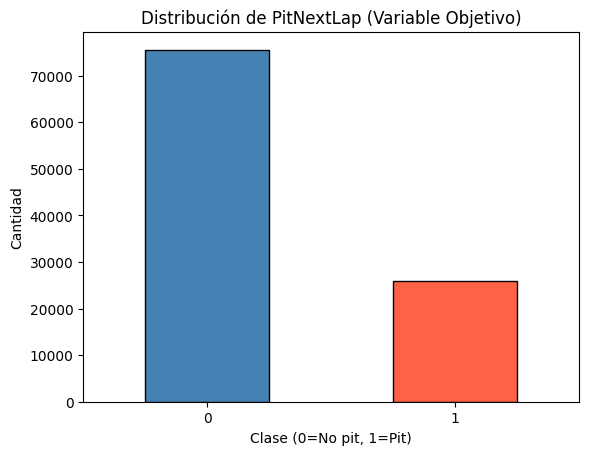

PitNextLap
0    75542
1    25829
Name: count, dtype: int64
PitNextLap
0    74.52
1    25.48
Name: proportion, dtype: float64


In [ ]:
# Distribución de la variable objetivo
data['PitNextLap'].value_counts().plot(kind='bar', color=['steelblue','tomato'], edgecolor='black')
plt.title('Distribución de PitNextLap (Variable Objetivo)')
plt.xlabel('Clase (0=No pit, 1=Pit)')
plt.ylabel('Cantidad')
plt.xticks(rotation=0)
plt.show()
print(data['PitNextLap'].value_counts())
print(data['PitNextLap'].value_counts(normalize=True).mul(100).round(2))

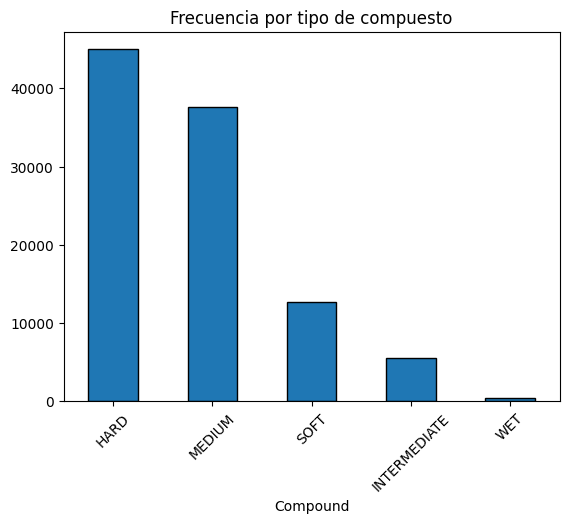

In [ ]:
# Descripción variables categóricas
data['Compound'].value_counts().plot(kind='bar', edgecolor='black')
plt.title('Frecuencia por tipo de compuesto')
plt.xticks(rotation=45)
plt.show()

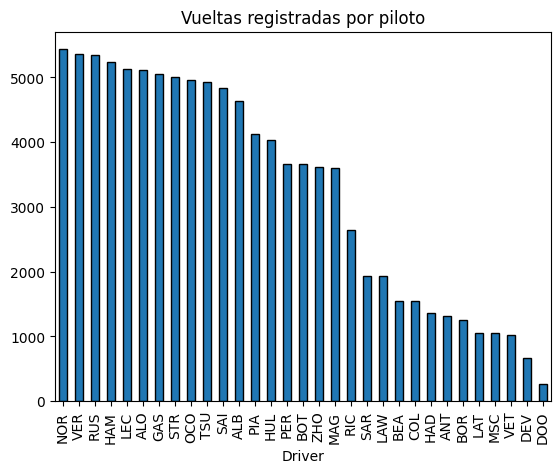

In [ ]:
data['Driver'].value_counts().plot(kind='bar', edgecolor='black')
plt.title('Vueltas registradas por piloto')
plt.xticks(rotation=90)
plt.show()

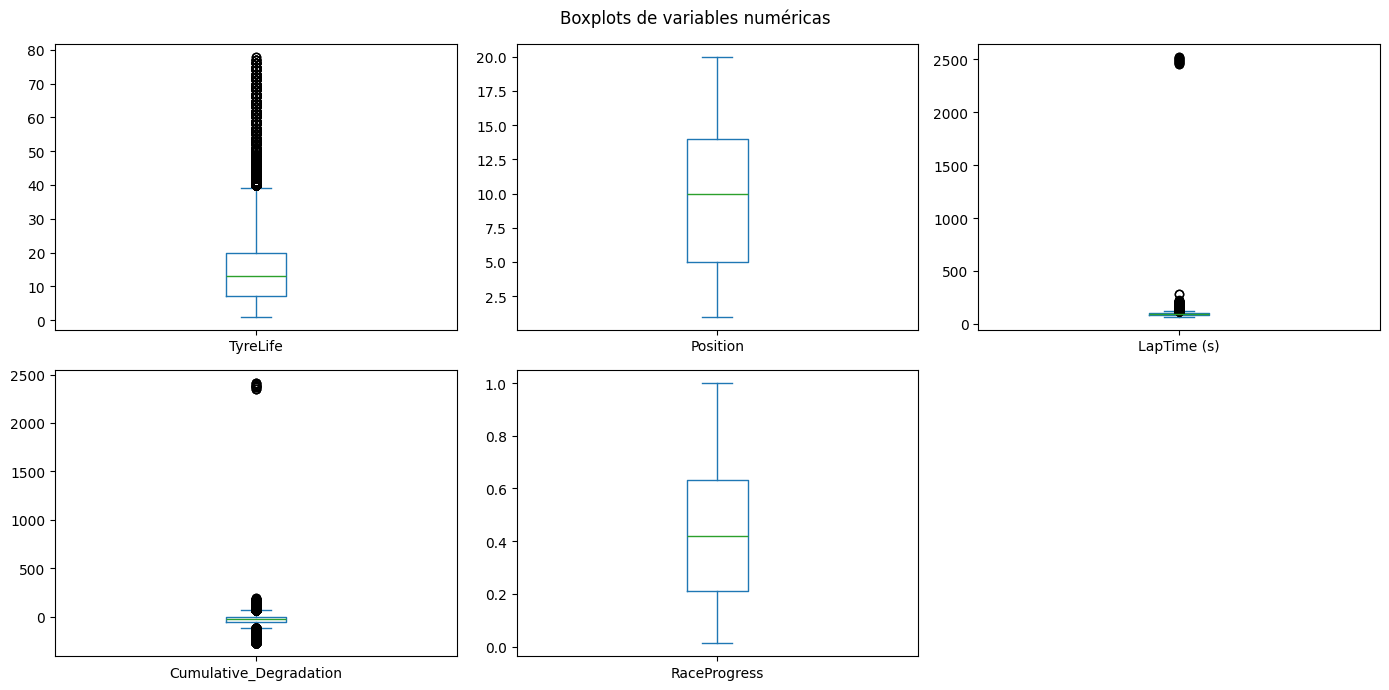

In [ ]:
# Boxplots de variables numéricas
cols_num = ['TyreLife', 'Position', 'LapTime (s)', 'Cumulative_Degradation', 'RaceProgress']
data[cols_num].plot(kind='box', subplots=True, layout=(2,3), figsize=(14,7))
plt.suptitle('Boxplots de variables numéricas')
plt.tight_layout()
plt.show()

# 2. Preparación de Datos

In [ ]:
# Verificar valores nulos
print('Valores nulos por variable:')
print(data.isnull().sum())

Valores nulos por variable:
Driver                     0
LapNumber                  0
Compound                  66
Stint                      0
TyreLife                   0
Position                   0
LapTime (s)                0
Race                       0
Year                       0
LapTime_Delta              0
Cumulative_Degradation     0
PitStop                    0
PitNextLap                 0
RaceProgress               0
Normalized_TyreLife        0
Position_Change            0
dtype: int64


In [ ]:
# Limpieza de atípicos en LapTime (s)
# Vueltas con tiempo > 150 segundos corresponden a safety car o problemas mecánicos
print(f'Registros con LapTime > 150s: {(data["LapTime (s)"] > 150).sum()}')

mediana_laptime = data.groupby('Race')['LapTime (s)'].transform('median')
mask = data['LapTime (s)'] > 150
data.loc[mask, 'LapTime (s)'] = mediana_laptime[mask]
print(f'Atípicos corregidos con mediana por carrera')

Registros con LapTime > 150s: 112
Atípicos corregidos con mediana por carrera


In [ ]:
# Selección de variables relevantes para el modelo
# Se excluyen: Driver (alta cardinalidad), Race (alta cardinalidad), Year (constante=2023),
#              LapNumber (redundante con RaceProgress), PitStop (variable de la vuelta actual)
columnas_modelo = [
    'Compound', 'Stint', 'TyreLife', 'Position', 'LapTime (s)',
    'LapTime_Delta', 'Cumulative_Degradation', 'RaceProgress',
    'Normalized_TyreLife', 'Position_Change', 'PitNextLap'
]
data = data[columnas_modelo].copy()
print(f'Variables seleccionadas: {data.shape[1]-1} predictoras + 1 objetivo')
data.head()

Variables seleccionadas: 10 predictoras + 1 objetivo


,Compound,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Normalized_TyreLife,Position_Change,PitNextLap
0,MEDIUM,1,2.0,17,100.625,0.000,0.000,0.017241,0.117647,0.0,0
1,MEDIUM,1,3.0,18,93.560,-7.065,-7.065,0.034483,0.176471,-1.0,0
2,MEDIUM,1,4.0,18,91.768,-1.792,-8.857,0.051724,0.235294,0.0,0
3,MEDIUM,1,5.0,18,91.591,-0.177,-9.034,0.068966,0.294118,0.0,0
4,MEDIUM,1,6.0,18,91.422,-0.169,-9.203,0.086207,0.352941,0.0,0


In [ ]:
# Codificación ordinal de Compound (no One-Hot para evitar dummies innecesarias)
compound_map = {'SOFT': 3, 'MEDIUM': 2, 'HARD': 1, 'INTERMEDIATE': 1.5, 'WET': 1.5}
data['Compound'] = data['Compound'].map(compound_map)
print('Codificación de Compound aplicada:')
print(compound_map)
data.head()

Codificación de Compound aplicada:
{'SOFT': 3, 'MEDIUM': 2, 'HARD': 1, 'INTERMEDIATE': 1.5, 'WET': 1.5}


,Compound,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Normalized_TyreLife,Position_Change,PitNextLap
0,2.0,1,2.0,17,100.625,0.000,0.000,0.017241,0.117647,0.0,0
1,2.0,1,3.0,18,93.560,-7.065,-7.065,0.034483,0.176471,-1.0,0
2,2.0,1,4.0,18,91.768,-1.792,-8.857,0.051724,0.235294,0.0,0
3,2.0,1,5.0,18,91.591,-0.177,-9.034,0.068966,0.294118,0.0,0
4,2.0,1,6.0,18,91.422,-0.169,-9.203,0.086207,0.352941,0.0,0


# 3. División 70-30

In [ ]:
# División 70-30 estratificada
from sklearn.model_selection import train_test_split

X = data.drop('PitNextLap', axis=1)   # Variables predictoras
Y = data['PitNextLap']                 # Variable objetivo

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.30, random_state=42, stratify=Y  # stratify mantiene proporción de clases
)

print(f'Total registros : {len(data):,}')
print(f'Entrenamiento   : {len(X_train):,} (70%)')
print(f'Prueba          : {len(X_test):,}  (30%)')

Total registros : 101,371
Entrenamiento   : 70,959 (70%)
Prueba          : 30,412  (30%)


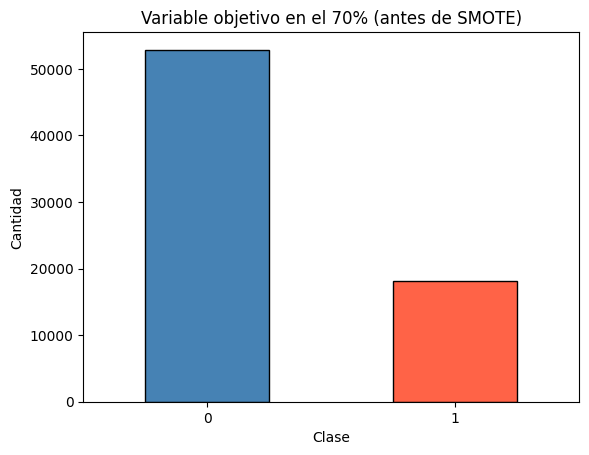

PitNextLap
0    52879
1    18080
Name: count, dtype: int64


In [ ]:
# Distribución de la variable objetivo en el 70%
Y_train.value_counts().plot(kind='bar', color=['steelblue','tomato'], edgecolor='black')
plt.title('Variable objetivo en el 70% (antes de SMOTE)')
plt.xlabel('Clase'); plt.ylabel('Cantidad'); plt.xticks(rotation=0)
plt.show()
print(Y_train.value_counts())

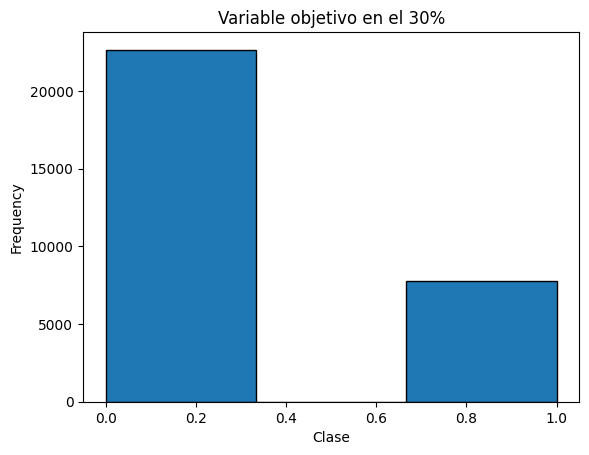

In [ ]:
# Distribución de la variable objetivo en el 30%
Y_test.plot(kind='hist', bins=3, edgecolor='black')
plt.title('Variable objetivo en el 30%')
plt.xlabel('Clase')
plt.show()

# 4. Balanceo con SMOTE (solo sobre el 70%)

In [ ]:
from imblearn.over_sampling import SMOTE

# Before applying SMOTE, handle NaN values in X_train.
# The 'Compound' column was identified as having missing values in earlier steps
# and these NaNs were preserved after numerical mapping. We will impute them with the mode.
if X_train['Compound'].isnull().any():
    mode_compound = X_train['Compound'].mode()[0]
    X_train['Compound'].fillna(mode_compound, inplace=True)
    print(f"Filled NaN values in 'Compound' column of X_train with mode: {mode_compound}")

smote = SMOTE(random_state=42, k_neighbors=5)
X_train_bal, Y_train_bal = smote.fit_resample(X_train, Y_train)

print('Distribución DESPUÉS de SMOTE (70% balanceado):')
print(pd.Series(Y_train_bal).value_counts())

Filled NaN values in 'Compound' column of X_train with mode: 1.0
Distribución DESPUÉS de SMOTE (70% balanceado):
PitNextLap
0    52879
1    52879
Name: count, dtype: int64


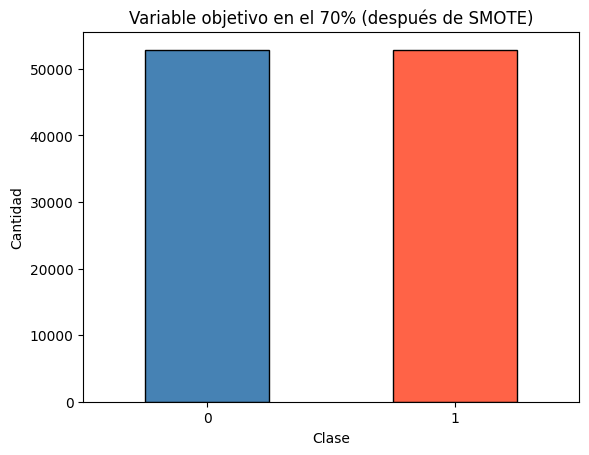

In [ ]:
pd.Series(Y_train_bal).value_counts().plot(
    kind='bar', color=['steelblue','tomato'], edgecolor='black'
)
plt.title('Variable objetivo en el 70% (después de SMOTE)')
plt.xlabel('Clase'); plt.ylabel('Cantidad'); plt.xticks(rotation=0)
plt.show()

# 5. Normalización de variables numéricas
- Árbol de decisión y ensambles basados en árboles: **NO se normalizan**
- KNN, Red Neuronal, SVM: **SÍ se normalizan**

In [ ]:
from sklearn.preprocessing import MinMaxScaler

min_max_scaler = MinMaxScaler()

variables_numericas = [
    'Stint', 'TyreLife', 'Position', 'LapTime (s)',
    'LapTime_Delta', 'Cumulative_Degradation', 'RaceProgress',
    'Normalized_TyreLife', 'Position_Change', 'Compound'
]

# Ajuste sobre los datos de entrenamiento balanceados
X_train_bal_df = pd.DataFrame(X_train_bal, columns=X.columns)
X_test_df      = pd.DataFrame(X_test.values, columns=X.columns)

min_max_scaler.fit(X_train_bal_df[variables_numericas])

# Copias normalizadas para KNN, NN, SVM
X_train_norm = X_train_bal_df.copy()
X_test_norm  = X_test_df.copy()

X_train_norm[variables_numericas] = min_max_scaler.transform(X_train_bal_df[variables_numericas])
X_test_norm[variables_numericas]  = min_max_scaler.transform(X_test_df[variables_numericas])

print('Normalización aplicada ')
X_train_norm.head()

Normalización aplicada 


,Compound,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Normalized_TyreLife,Position_Change
0,0.0,0.142857,0.116883,0.052632,0.199978,0.491329,0.101532,0.298701,0.116883,0.628571
1,0.0,0.285714,0.103896,0.684211,0.506269,0.501619,0.100533,0.407995,0.214935,0.657143
2,0.0,0.142857,0.000000,1.000000,0.580864,0.502916,0.080726,0.394839,0.005431,0.400000
3,0.0,0.142857,0.454545,0.526316,0.488078,0.501120,0.099313,0.652690,0.876465,0.571429
4,0.0,0.285714,0.246753,0.368421,0.171432,0.493275,0.068715,0.733424,0.662338,0.571429


# 6. Guardamos artefactos para el Notebook de Modelamiento

In [ ]:
import pickle

# Guardamos todo lo necesario para el notebook de modelamiento
variables = X.columns.values

pickle.dump([
    X_train_bal_df,   # 70% sin normalizar (para árboles y ensambles)
    X_train_norm,     # 70% normalizado (para KNN, NN, SVM)
    X_test_df,        # 30% sin normalizar
    X_test_norm,      # 30% normalizado
    Y_train_bal,      # Y del 70% balanceado
    Y_test,           # Y del 30%
    min_max_scaler,   # Scaler entrenado
    compound_map,     # Mapa de codificación
    variables         # Nombres de variables
], open('datos_preparados.pkl', 'wb'))

print('Artefactos guardados en datos_preparados.pkl ')
print(f'Variables del modelo: {list(variables)}')

Artefactos guardados en datos_preparados.pkl 
Variables del modelo: ['Compound', 'Stint', 'TyreLife', 'Position', 'LapTime (s)', 'LapTime_Delta', 'Cumulative_Degradation', 'RaceProgress', 'Normalized_TyreLife', 'Position_Change']


In [ ]:
# Análisis de correlaciones con la variable objetivo
from scipy import stats

print('Correlación punto-biserial con PitNextLap:')
Y_completo = data['PitNextLap']
for col in variables_numericas:
    r, p = stats.pointbiserialr(Y_completo, data[col])
    sig = '✅' if p < 0.05 else '❌'
    print(f'  {sig} {col:30s} r={r:+.4f}  p={p:.4f}')

Correlación punto-biserial con PitNextLap:
  ✅ Stint                          r=+0.0870  p=0.0000
  ✅ TyreLife                       r=+0.2662  p=0.0000
  ✅ Position                       r=-0.0322  p=0.0000
  ✅ LapTime (s)                    r=-0.0212  p=0.0000
  ❌ LapTime_Delta                  r=+0.0036  p=0.2552
  ✅ Cumulative_Degradation         r=-0.1223  p=0.0000
  ✅ RaceProgress                   r=+0.0992  p=0.0000
  ✅ Normalized_TyreLife            r=+0.1254  p=0.0000
  ✅ Position_Change                r=+0.0575  p=0.0000
  ❌ Compound                       r=+nan  p=nan


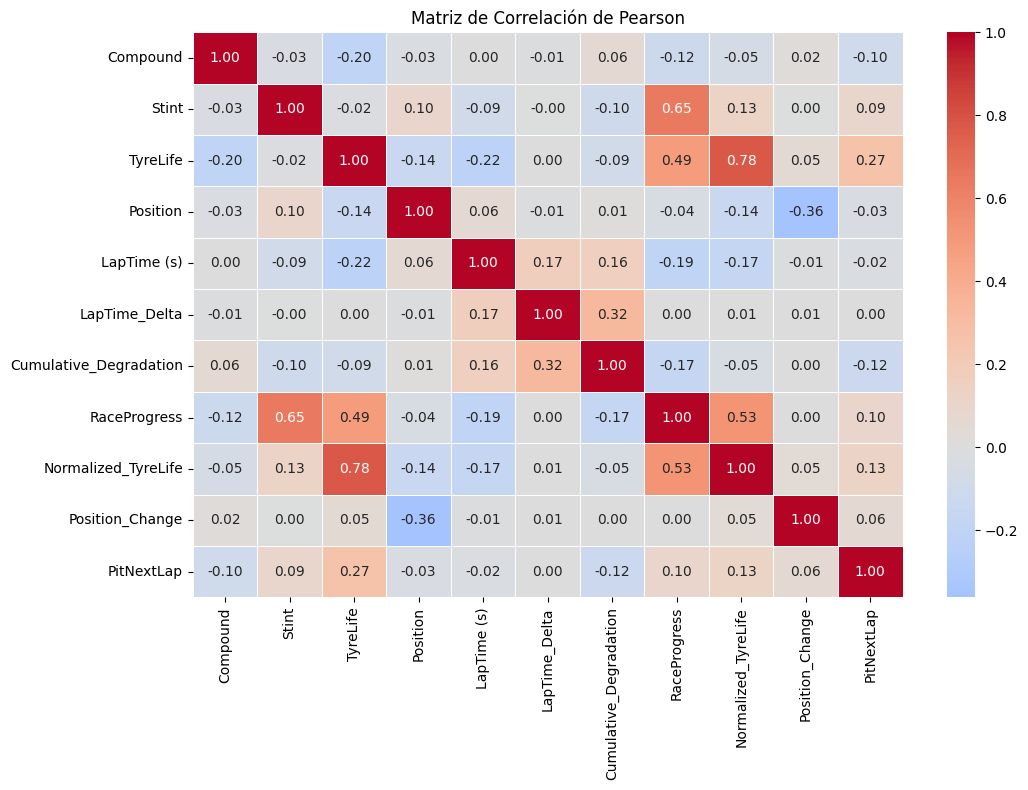

In [ ]:
# Matriz de correlación
corr = data.corr(numeric_only=True)
plt.figure(figsize=(11, 8))
import seaborn as sns
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Matriz de Correlación de Pearson')
plt.tight_layout()
plt.show()